In [2]:
from google.colab import files
files.upload()

Saving heart.csv to heart.csv


{'heart.csv': b'Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease\n40,M,ATA,140,289,0,Normal,172,N,0,Up,0\n49,F,NAP,160,180,0,Normal,156,N,1,Flat,1\n37,M,ATA,130,283,0,ST,98,N,0,Up,0\n48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1\n54,M,NAP,150,195,0,Normal,122,N,0,Up,0\n39,M,NAP,120,339,0,Normal,170,N,0,Up,0\n45,F,ATA,130,237,0,Normal,170,N,0,Up,0\n54,M,ATA,110,208,0,Normal,142,N,0,Up,0\n37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1\n48,F,ATA,120,284,0,Normal,120,N,0,Up,0\n37,F,NAP,130,211,0,Normal,142,N,0,Up,0\n58,M,ATA,136,164,0,ST,99,Y,2,Flat,1\n39,M,ATA,120,204,0,Normal,145,N,0,Up,0\n49,M,ASY,140,234,0,Normal,140,Y,1,Flat,1\n42,F,NAP,115,211,0,ST,137,N,0,Up,0\n54,F,ATA,120,273,0,Normal,150,N,1.5,Flat,0\n38,M,ASY,110,196,0,Normal,166,N,0,Flat,1\n43,F,ATA,120,201,0,Normal,165,N,0,Up,0\n60,M,ASY,100,248,0,Normal,125,N,1,Flat,1\n36,M,ATA,120,267,0,Normal,160,N,3,Flat,1\n43,F,TA,100,223,0,Normal,142,N,0,Up,0\n44,M,ATA,120,184,0

In [128]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [129]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [131]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

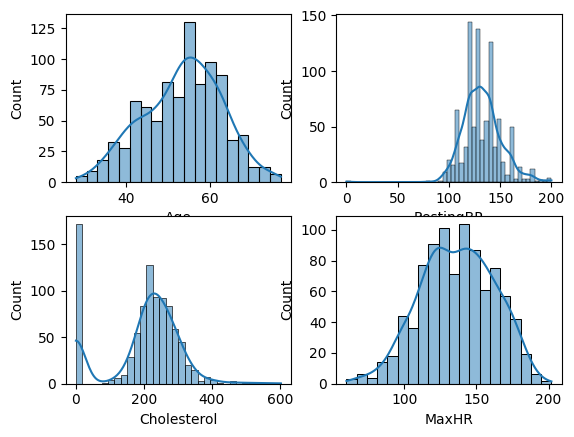

In [132]:
def ploting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(data=df,x=var,kde=True)
  plt.xlabel(var)


ploting('Age',1)
ploting('RestingBP',2)
ploting('Cholesterol',3)
ploting('MaxHR',4)



In [133]:
# Replacing cholesterol zero with its mean
cholesterol_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0,cholesterol_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [134]:
#Replacing resting bp zero with mean
restingbp_mean = df.loc[df['RestingBP'] != 0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,restingbp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

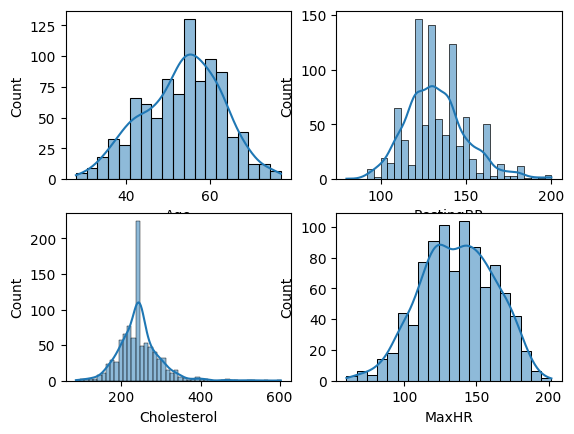

In [135]:
ploting('Age',1)
ploting('RestingBP',2)
ploting('Cholesterol',3)
ploting('MaxHR',4)


In [136]:
df_encoded = pd.get_dummies(df,drop_first=True)
df_encoded = df_encoded.astype(int)

In [137]:
df_encoded.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [138]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [139]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [141]:
scaler = StandardScaler()
X_train_sclaed = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [142]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC()
}
results = []

In [143]:
for name,modle in models.items():
  modle.fit(X_train_sclaed,y_train)
  y_pred = modle.predict(X_test_scaled)
  accu = accuracy_score(y_test,y_pred)
  f1 = f1_score(y_test,y_pred)
  results.append({
      'Model': name,
      'Accuracy': round(accu,4),
      'F1_Score': round(f1,4)
  })

In [144]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.8696, 'F1_Score': 0.8857},
 {'Model': 'Decision Tree', 'Accuracy': 0.7826, 'F1_Score': 0.8039},
 {'Model': 'Naive Bayes', 'Accuracy': 0.8533, 'F1_Score': 0.8683},
 {'Model': 'K-Nearest Neighbors', 'Accuracy': 0.8641, 'F1_Score': 0.8815},
 {'Model': 'Support Vector Machine', 'Accuracy': 0.8478, 'F1_Score': 0.8679}]

In [145]:
import joblib
joblib.dump(models['Logistic Regression'],'LogisticRegression.pkl')
joblib.dump(models['K-Nearest Neighbors'],'KNN.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']